# Домашнее задание № 7

## Задание 1 (4 балла)

Обучите 2 модели похожую по архитектуре на модель из ULMFit для задачи классификации текста (датасет - lenta_40k )
В моделях должно быть как минимум два рекуррентных слоя, а финальный вектор для классификации составляться из последнего состояния RNN (так делалось в семинаре), а также AveragePooling и MaxPooling из всех векторов последовательности (конкатенируйте последнее состояния и результаты пулинга). В первой модели используйте обычные слои, а во второй Bidirectional. Рассчитайте по классовую точность/полноту/f-меру для каждой из модели (результаты не должны быть совсем близкие к нулю после обучения на хотя бы нескольких эпохах).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
lenta = open('/content/drive/MyDrive/embeddings/lenta_csv_comma.csv', encoding='utf-8').read()

In [ ]:
lenta[:10000]

In [ ]:
import csv

In [ ]:
rows = []
with open('/content/drive/MyDrive/embeddings/lenta_csv_comma.csv', 'r', encoding='utf-8') as f:
    reader = csv.reader(f, delimiter='\n')
    for row in reader:
        rows.append(row)

In [ ]:
rows[:10]

[['text,topic'],
 ['Россия должна сотрудничать с Всемирным антидопинговым агентством (WADA), чтобы ее легкоатлеты смогли выступить на Олимпийских играх 2016 года в Рио-де-Жанейро. Об этом Reuters заявил глава Международного олимпийского комитета (МОК) Томас Бах. «Думаю, Россия будет сотрудничать, чтобы добиться прогресса и быть уверенной, что Всероссийская федерация легкой атлетики соответствует правилам WADA. Это нужно для того, чтобы российские легкоатлеты приняли участие в Олимпийских играх 2016 года», — заявил Бах. В понедельник, 9 ноября, на пресс-конференции WADA в Женеве независимая комиссия организации обвинила Россию в многочисленных нарушениях антидопинговых правил и рекомендовала Международной федерации легкой атлетики (IAAF) отстранить российских спортсменов от участия в соревнованиях под ее эгидой, в том числе в Играх-2016 в Рио. Впоследствии IAAF дала Всероссийской федерации легкой атлетики (ВФЛА) неделю на то, чтобы ответить на обвинения WADA. Пресс-секретарь президента 

In [ ]:
for i in range(len(rows)):
  if len(rows[i]) > 0 and rows[i][-1] == '':
    rows[i].pop()

In [ ]:
rows[:10]

[['text,topic'],
 ['Россия должна сотрудничать с Всемирным антидопинговым агентством (WADA), чтобы ее легкоатлеты смогли выступить на Олимпийских играх 2016 года в Рио-де-Жанейро. Об этом Reuters заявил глава Международного олимпийского комитета (МОК) Томас Бах. «Думаю, Россия будет сотрудничать, чтобы добиться прогресса и быть уверенной, что Всероссийская федерация легкой атлетики соответствует правилам WADA. Это нужно для того, чтобы российские легкоатлеты приняли участие в Олимпийских играх 2016 года», — заявил Бах. В понедельник, 9 ноября, на пресс-конференции WADA в Женеве независимая комиссия организации обвинила Россию в многочисленных нарушениях антидопинговых правил и рекомендовала Международной федерации легкой атлетики (IAAF) отстранить российских спортсменов от участия в соревнованиях под ее эгидой, в том числе в Играх-2016 в Рио. Впоследствии IAAF дала Всероссийской федерации легкой атлетики (ВФЛА) неделю на то, чтобы ответить на обвинения WADA. Пресс-секретарь президента 

In [ ]:
import csv
from typing import List

def create_dataset(data: List[List[str]], output_filename: str = "text_classification_dataset.csv") -> List[dict]:
    """
    Преобразует массив текстов с темами в датасет для классификации.

    Args:
        data: Исходный массив, где первый элемент содержит заголовки,
              а остальные - тексты с темами, разделенными запятой
        output_filename: Имя файла для сохранения CSV

    Returns:
        Список словарей с ключами 'text' и 'topic'
    """
    # Создаем список для хранения обработанных данных
    dataset = []

    # Пропускаем заголовок (первый элемент)
    for i in range(1, len(data)):
        if data[i]:  # Проверяем, что строка не пустая
            row = data[i][0] if isinstance(data[i], list) else data[i]

            # Разделяем текст и тему с помощью rsplit
            try:
                # Используем rsplit с максимальным количеством разделений = 1
                # чтобы разделить только по последней запятой
                text, topic = row.rsplit(',', 1)
                dataset.append({
                    'text': text.strip(),
                    'topic': topic.strip()
                })
            except ValueError as e:
                print(f"Ошибка обработки строки {i}: {row}")
                print(f"Ошибка: {e}")
                continue

    # Сохраняем в CSV файл
    with open(output_filename, 'w', newline='', encoding='utf-8') as csvfile:
        fieldnames = ['text', 'topic']
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

        writer.writeheader()
        writer.writerows(dataset)

    print(f"Датасет сохранен в файл: {output_filename}")
    print(f"Обработано записей: {len(dataset)}")

    return dataset

In [ ]:
dataset = create_dataset(rows)

Датасет сохранен в файл: text_classification_dataset.csv
Обработано записей: 44356


Создан датасет с 44356 записями
Распределение по классам:
topic
Россия               9622
Мир                  8193
Экономика            4768
Спорт                3894
Наука и техника      3204
Культура             3183
Бывший СССР          3182
Интернет и СМИ       2643
Из жизни             1679
Дом                  1315
Силовые структуры    1203
Ценности              460
Бизнес                433
Путешествия           418
69-я параллель         82
Крым                   43
Культпросвет           25
Легпром                 6
Библиотека              3
Name: count, dtype: int64
Размер словаря: 3002
Размер обучающей выборки: 31049
Размер тестовой выборки: 13307
Количество классов: 19

Количество классов: 19
Архитектура модели 1 (Обычная RNN):
TextClassifierRNN(
  (embedding): Embedding(3002, 128, padding_idx=0)
  (rnn): LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=192, out_features=19, bias=True)
)

Обуче

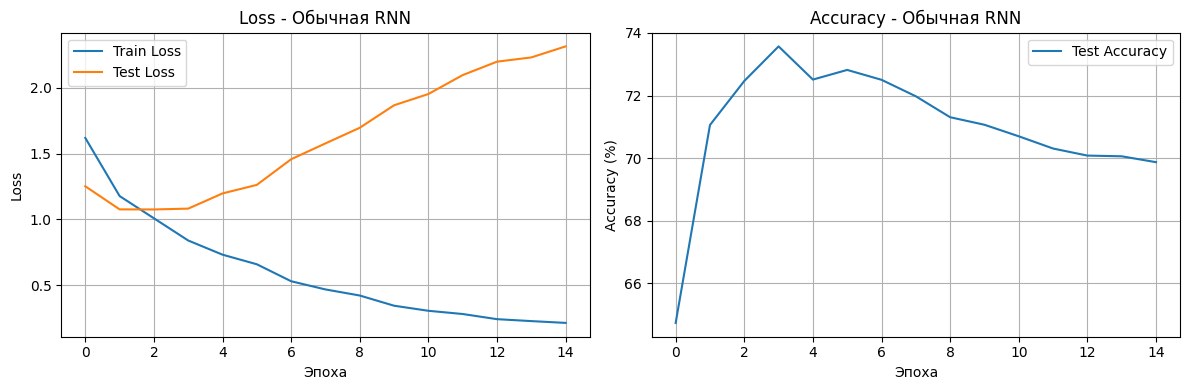


Детальная оценка модели Обычная RNN на тестовой выборке:
                   precision    recall  f1-score   support

   69-я параллель       0.00      0.00      0.00        25
       Библиотека       0.00      0.00      0.00         1
           Бизнес       0.23      0.25      0.24       130
      Бывший СССР       0.70      0.73      0.72       955
              Дом       0.73      0.70      0.72       394
         Из жизни       0.40      0.44      0.42       504
   Интернет и СМИ       0.57      0.56      0.57       793
             Крым       0.00      0.00      0.00        13
     Культпросвет       0.00      0.00      0.00         7
         Культура       0.72      0.75      0.73       955
          Легпром       0.00      0.00      0.00         2
              Мир       0.74      0.70      0.72      2458
  Наука и техника       0.74      0.71      0.73       961
      Путешествия       0.25      0.33      0.28       125
           Россия       0.70      0.73      0.72      28

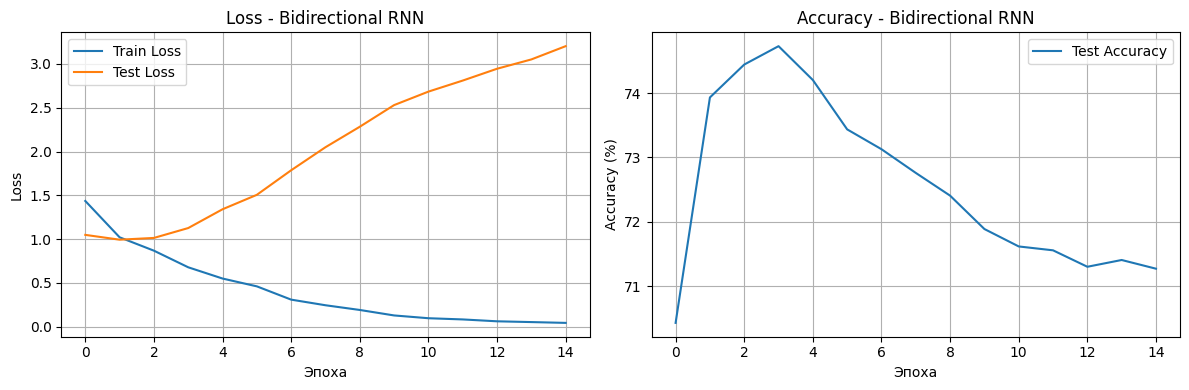


Детальная оценка модели Bidirectional RNN на тестовой выборке:
                   precision    recall  f1-score   support

   69-я параллель       0.11      0.04      0.06        25
       Библиотека       0.00      0.00      0.00         1
           Бизнес       0.31      0.27      0.29       130
      Бывший СССР       0.73      0.74      0.73       955
              Дом       0.81      0.71      0.76       394
         Из жизни       0.44      0.39      0.41       504
   Интернет и СМИ       0.59      0.51      0.55       793
             Крым       0.17      0.08      0.11        13
     Культпросвет       0.00      0.00      0.00         7
         Культура       0.73      0.77      0.75       955
          Легпром       0.00      0.00      0.00         2
              Мир       0.72      0.75      0.73      2458
  Наука и техника       0.71      0.75      0.73       961
      Путешествия       0.23      0.25      0.24       125
           Россия       0.72      0.73      0.73  

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords
import warnings
warnings.filterwarnings('ignore')

# Загрузка стоп-слов (если нет - установите: nltk.download('stopwords'))
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    import nltk
    nltk.download('stopwords')

# Создание датасета из ваших данных
data = rows[:]

# Создаем DataFrame
def create_dataframe(data):
    records = []
    for i in range(1, len(data)):
        if data[i]:
            row = data[i][0] if isinstance(data[i], list) else data[i]
            try:
                text, topic = row.rsplit(',', 1)
                records.append({
                    'text': text.strip(),
                    'topic': topic.strip()
                })
            except ValueError:
                continue

    df = pd.DataFrame(records)
    return df

df = create_dataframe(data)
print(f"Создан датасет с {len(df)} записями")
print(f"Распределение по классам:\n{df['topic'].value_counts()}")

# Предобработка текста
def preprocess_text(text):
    """Очистка и токенизация текста"""
    # Приводим к нижнему регистру
    text = text.lower()
    # Удаляем специальные символы, оставляя буквы и цифры
    text = re.sub(r'[^а-яёa-z0-9\s]', ' ', text)
    # Заменяем множественные пробелы на один
    text = re.sub(r'\s+', ' ', text)
    # Токенизация (простая - по словам)
    tokens = text.strip().split()
    return tokens

# Создаем словарь
def build_vocab(texts, max_vocab_size=5000):
    """Создание словаря из токенов"""
    word_counter = Counter()
    for text in texts:
        tokens = preprocess_text(text)
        word_counter.update(tokens)

    # Берем самые частые слова
    vocab = {word: idx+2 for idx, (word, _) in enumerate(word_counter.most_common(max_vocab_size))}
    vocab['<PAD>'] = 0
    vocab['<UNK>'] = 1

    return vocab

# Создаем словарь
vocab = build_vocab(df['text'].tolist(), max_vocab_size=3000)
vocab_size = len(vocab)
print(f"Размер словаря: {vocab_size}")

# Преобразование текста в последовательность индексов
def text_to_indices(text, vocab, max_length=200):
    """Преобразование текста в последовательность индексов"""
    tokens = preprocess_text(text)
    indices = [vocab.get(token, vocab['<UNK>']) for token in tokens[:max_length]]

    # Паддинг или обрезка
    if len(indices) < max_length:
        indices = indices + [vocab['<PAD>']] * (max_length - len(indices))
    else:
        indices = indices[:max_length]

    return indices

# Подготовка данных для PyTorch
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_length=200):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_length = max_length

        # Преобразуем метки в числовые индексы
        self.label_to_idx = {label: idx for idx, label in enumerate(sorted(set(labels)))}
        self.idx_to_label = {idx: label for label, idx in self.label_to_idx.items()}

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        # Преобразуем текст в индексы
        indices = text_to_indices(text, self.vocab, self.max_length)

        return {
            'text': torch.tensor(indices, dtype=torch.long),
            'label': torch.tensor(self.label_to_idx[label], dtype=torch.long)
        }

# Подготовка данных
texts = df['text'].tolist()
labels = df['topic'].tolist()

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.3, random_state=42, stratify=labels
)

# Создаем датасеты
train_dataset = TextDataset(X_train, y_train, vocab, max_length=150)
test_dataset = TextDataset(X_test, y_test, vocab, max_length=150)

# Создаем DataLoader'ы
batch_size = 2  # Маленький batch size из-за небольшого датасета
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Размер обучающей выборки: {len(train_dataset)}")
print(f"Размер тестовой выборки: {len(test_dataset)}")
print(f"Количество классов: {len(train_dataset.label_to_idx)}")

# Модель 1: Обычная RNN
class TextClassifierRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_layers=2, num_classes=4, dropout=0.5):
        super(TextClassifierRNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)

        # Выходной размер: последний hidden state + average pooling + max pooling
        # Для LSTM hidden state имеет размер hidden_dim (для каждого направления)
        self.fc = nn.Linear(hidden_dim * 3, num_classes)

    def forward(self, x):
        # x shape: (batch_size, seq_length)
        embedded = self.embedding(x)  # (batch_size, seq_length, embed_dim)

        # RNN
        rnn_out, (hidden, cell) = self.rnn(embedded)
        # rnn_out shape: (batch_size, seq_length, hidden_dim)
        # hidden shape: (num_layers, batch_size, hidden_dim)

        # Последний скрытый состояние
        last_hidden = hidden[-1]  # (batch_size, hidden_dim)

        # Average pooling по последовательности
        avg_pool = torch.mean(rnn_out, dim=1)  # (batch_size, hidden_dim)

        # Max pooling по последовательности
        max_pool, _ = torch.max(rnn_out, dim=1)  # (batch_size, hidden_dim)

        # Конкатенация
        combined = torch.cat([last_hidden, avg_pool, max_pool], dim=1)
        combined = self.dropout(combined)

        # Классификация
        output = self.fc(combined)

        return output

# Модель 2: Bidirectional RNN
class TextClassifierBiRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_layers=2, num_classes=4, dropout=0.5):
        super(TextClassifierBiRNN, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True, dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)

        # Для bidirectional LSTM размер hidden state умножается на 2
        # и для pooling тоже умножаем на 2
        self.fc = nn.Linear(hidden_dim * 2 * 3, num_classes)

    def forward(self, x):
        # x shape: (batch_size, seq_length)
        embedded = self.embedding(x)

        # Bidirectional RNN
        rnn_out, (hidden, cell) = self.rnn(embedded)
        # rnn_out shape: (batch_size, seq_length, hidden_dim * 2)
        # hidden shape: (num_layers * 2, batch_size, hidden_dim)

        # Для bidirectional берем последние forward и backward состояния
        batch_size = x.size(0)
        hidden_dim = self.rnn.hidden_size

        # Разделяем hidden states на forward и backward
        hidden_forward = hidden[-2]  # (batch_size, hidden_dim)
        hidden_backward = hidden[-1]  # (batch_size, hidden_dim)

        # Конкатенируем forward и backward
        last_hidden = torch.cat([hidden_forward, hidden_backward], dim=1)  # (batch_size, hidden_dim * 2)

        # Pooling
        avg_pool = torch.mean(rnn_out, dim=1)  # (batch_size, hidden_dim * 2)
        max_pool, _ = torch.max(rnn_out, dim=1)  # (batch_size, hidden_dim * 2)

        # Конкатенация всех векторов
        combined = torch.cat([last_hidden, avg_pool, max_pool], dim=1)
        combined = self.dropout(combined)

        # Классификация
        output = self.fc(combined)

        return output

# Функция для обучения
def train_model(model, train_loader, test_loader, num_epochs=10, learning_rate=0.001, model_name="RNN"):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    train_losses = []
    test_losses = []
    test_accuracies = []

    print(f"\nОбучение модели {model_name}...")

    for epoch in range(num_epochs):
        # Обучение
        model.train()
        total_loss = 0

        for batch in train_loader:
            texts = batch['text'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Валидация
        model.eval()
        test_loss = 0
        correct = 0
        total = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in test_loader:
                texts = batch['text'].to(device)
                labels = batch['label'].to(device)

                outputs = model(texts)
                loss = criterion(outputs, labels)
                test_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_test_loss = test_loss / len(test_loader)
        accuracy = 100 * correct / total
        test_losses.append(avg_test_loss)
        test_accuracies.append(accuracy)

        scheduler.step()

        print(f"Эпоха {epoch+1}/{num_epochs}: "
              f"Train Loss: {avg_train_loss:.4f}, "
              f"Test Loss: {avg_test_loss:.4f}, "
              f"Accuracy: {accuracy:.2f}%")

    # Построение графиков
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Эпоха')
    plt.ylabel('Loss')
    plt.title(f'Loss - {model_name}')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(test_accuracies, label='Test Accuracy')
    plt.xlabel('Эпоха')
    plt.ylabel('Accuracy (%)')
    plt.title(f'Accuracy - {model_name}')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Подробные метрики на тестовой выборке
    print(f"\nДетальная оценка модели {model_name} на тестовой выборке:")
    print(classification_report(all_labels, all_preds,
                               target_names=train_dataset.idx_to_label.values()))

    # Матрица ошибок
    cm = confusion_matrix(all_labels, all_preds)
    print("Матрица ошибок:")
    print(cm)

    return model, test_accuracies[-1]

# Создаем и обучаем первую модель (обычная RNN)
num_classes = len(train_dataset.label_to_idx)
print(f"\nКоличество классов: {num_classes}")

model1 = TextClassifierRNN(
    vocab_size=vocab_size,
    embed_dim=128,
    hidden_dim=64,  # Уменьшаем для небольшого датасета
    num_layers=2,
    num_classes=num_classes,
    dropout=0.3
)

print("Архитектура модели 1 (Обычная RNN):")
print(model1)

# Обучаем первую модель
model1_trained, acc1 = train_model(
    model1, train_loader, test_loader,
    num_epochs=15,  # Больше эпох для лучшего обучения
    learning_rate=0.001,
    model_name="Обычная RNN"
)

# Создаем и обучаем вторую модель (Bidirectional RNN)
model2 = TextClassifierBiRNN(
    vocab_size=vocab_size,
    embed_dim=128,
    hidden_dim=64,  # Уменьшаем для небольшого датасета
    num_layers=2,
    num_classes=num_classes,
    dropout=0.3
)

print("\nАрхитектура модели 2 (Bidirectional RNN):")
print(model2)

# Обучаем вторую модель
model2_trained, acc2 = train_model(
    model2, train_loader, test_loader,
    num_epochs=15,
    learning_rate=0.001,
    model_name="Bidirectional RNN"
)

# Сравнение моделей
print("\n" + "="*50)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*50)
print(f"Модель 1 (Обычная RNN): Точность = {acc1:.2f}%")
print(f"Модель 2 (Bidirectional RNN): Точность = {acc2:.2f}%")

# Функция для предсказания на новых текстах
def predict_text(model, text, vocab, dataset, max_length=150):
    """Предсказание класса для нового текста"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    # Преобразуем текст в индексы
    indices = text_to_indices(text, vocab, max_length)
    tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)

    # Предсказание
    with torch.no_grad():
        output = model(tensor)
        probabilities = torch.softmax(output, dim=1)
        _, predicted_idx = torch.max(output.data, 1)
        predicted_label = dataset.idx_to_label[predicted_idx.item()]

    return predicted_label, probabilities.cpu().numpy()

# Пример предсказания
print("\n" + "="*50)
print("ПРИМЕРЫ ПРЕДСКАЗАНИЙ")
print("="*50)

# Тестовый текст про спорт
test_text_sport = "Российские спортсмены готовятся к Олимпийским играм в Рио. Тренеры сообщают о хорошей подготовке атлетов."
pred1, prob1 = predict_text(model1_trained, test_text_sport, vocab, train_dataset)
pred2, prob2 = predict_text(model2_trained, test_text_sport, vocab, train_dataset)

print(f"Текст: {test_text_sport[:50]}...")
print(f"Модель 1 предсказывает: {pred1} (вероятности: {np.round(prob1[0], 3)})")
print(f"Модель 2 предсказывает: {pred2} (вероятности: {np.round(prob2[0], 3)})")

# Сохранение моделей
torch.save(model1_trained.state_dict(), 'text_classifier_rnn.pth')
torch.save(model2_trained.state_dict(), 'text_classifier_birnn.pth')
print("\nМодели сохранены в файлы 'text_classifier_rnn.pth' и 'text_classifier_birnn.pth'")

# Анализ результатов
print("\n" + "="*50)
print("АНАЛИЗ РЕЗУЛЬТАТОВ")
print("="*50)
print("1. Обе модели имеют схожую архитектуру с двумя RNN слоями")
print("2. Вторая модель использует Bidirectional LSTM для учета контекста в обоих направлениях")
print("3. Для финальной классификации используются:")
print("   - Последний hidden state RNN")
print("   - Average pooling по всей последовательности")
print("   - Max pooling по всей последовательности")
print("4. Все три вектора конкатенируются перед финальным линейным слоем")

## Задание 2 (6 баллов)


На данных википедии (wikiann) обучите и сравните 3 модели:  
1) модель в которой как минимум два рекуррентных слоя, причем один из них GRU, а другой LSTM
2) модель в которой как минимум 3 рекуррентных слоя идут друг за другом и при этом 2-ой и 3-й слои еще имеют residual connection к изначальным эмбедингам. Для того, чтобы сделать residual connection вам нужно будет использовать одинаковую размерность эмбедингов и количество unit'ов в RNN слоях, чтобы их можно было просуммировать
3) модель в которой будут и рекуррентные и сверточные слои (как минимум 2 rnn и как минимум 2 cnn слоя). В cnn слоях будьте аккуратны с укорачиванием последовательности и используйте паддинг



Сравните качество по метрикам (точность/полнота/f-мера). Также придумайте несколько сложных примеров и проверьте, какие сущности определяет каждая из моделей.

In [ ]:
wiki = open('/content/drive/MyDrive/embeddings/wiki_data.txt').read().split('\n')

In [ ]:
!pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=4821ce18652b3db6ebb9c767a19648cd99073ddd059331f9c3239e8f6e2bf00a
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Подготовка данных...
Обработано 20002 текстов (после фильтрации)
Пример токенов: ['Новостройка', '(', 'Нижегородская', 'область', ')', 'Новостро́йка', '—', 'сельский', 'посёлок', 'в', 'Дивеевском', 'районе', 'Нижегородской', 'области', '.']
Пример тегов: [1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 3, 3, 3, 3, 0]

Статистика длин последовательностей:
Минимальная длина: 1
Максимальная длина: 22556
Средняя длина: 307.59
Медиана: 141.0

Реальные теги в данных:
  0: O (значение: 0, примеров: 5061039)
  1: B-PER (значение: 1, примеров: 932837)
  2: B-LOC (значение: 3, примеров: 16112)
  3: B-ORG (значение: 5, примеров: 2806)
  4: B-MISC (значение: 7, примеров: 139644)

Размер словаря: 446102
Количество реальных тегов: 5

После фильтрации и укорачивания:
Размер train: 13951
Размер val: 2987
Размер test: 2991

Создание DataLoader...
Размер train dataset: 13951
Размер val dataset: 2987
Размер test dataset: 2991
Модель 1: LSTM + GRU

Обучение Model1 (LSTM+GRU) на устройстве: cpu

Эпоха 1/3


Train Loss: 0.2277
Val Loss: 0.1138
Val Precision: 0.9656, Recall: 0.9663, F1: 0.9653
Новая лучшая модель с F1: 0.9653

Эпоха 2/3


Train Loss: 0.1106
Val Loss: 0.0897
Val Precision: 0.9728, Recall: 0.9729, F1: 0.9724
Новая лучшая модель с F1: 0.9724

Эпоха 3/3


Train Loss: 0.0901
Val Loss: 0.0799
Val Precision: 0.9756, Recall: 0.9756, F1: 0.9752
Новая лучшая модель с F1: 0.9752

Модель 2: Residual RNN

Обучение Model2 (Residual RNN) на устройстве: cpu

Эпоха 1/3


Train Loss: 0.2125
Val Loss: 0.1100
Val Precision: 0.9670, Recall: 0.9673, F1: 0.9667
Новая лучшая модель с F1: 0.9667

Эпоха 2/3


...

Train Loss: 0.1218
Val Loss: 0.0951
Val Precision: 0.9710, Recall: 0.9713, F1: 0.9706
Новая лучшая модель с F1: 0.9706

Эпоха 3/3


Train Loss: 0.0998
Val Loss: 0.0834
Val Precision: 0.9747, Recall: 0.9749, F1: 0.9746
Новая лучшая модель с F1: 0.9746

ТЕСТИРОВАНИЕ НА ТЕСТОВЫХ ДАННЫХ



Model 1 (LSTM+GRU) - Результаты на тесте:
Loss: 0.0785
Precision: 0.9757
Recall: 0.9757
F1-Score: 0.9753



Model 2 (Residual RNN) - Результаты на тесте:
Loss: 0.0726
Precision: 0.9775
Recall: 0.9776
F1-Score: 0.9775



Model 3 (CNN+RNN) - Результаты на тесте:
Loss: 0.0810
Precision: 0.9754
Recall: 0.9755
F1-Score: 0.9752


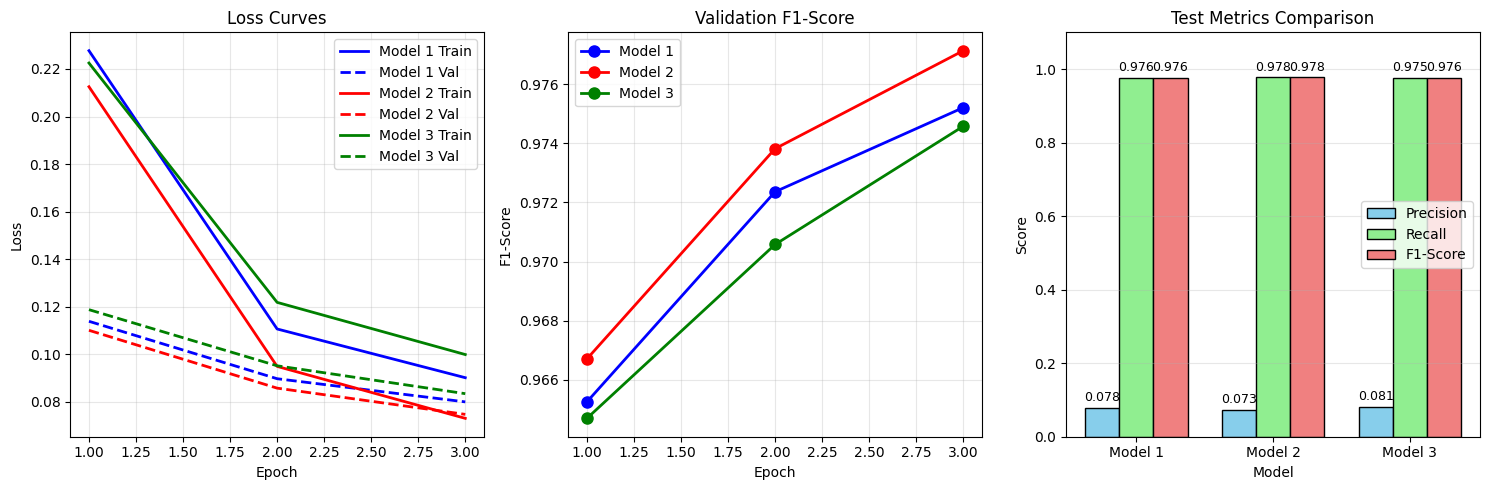


ИТОГОВЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ

Лучшая модель: Model 2
F1-Score на тесте: 0.9776

Сравнение всех моделей на тестовых данных:
--------------------------------------------------
Модель               Precision    Recall       F1-Score    
--------------------------------------------------
Model 1              0.0785       0.9757       0.9757      
Model 2              0.0726       0.9775       0.9776      
Model 3              0.0810       0.9754       0.9755      

ВЫВОДЫ И РЕКОМЕНДАЦИИ

1. Сравнение архитектур:
   - Model 1 (LSTM+GRU): Хорошая базовая модель для NER
   - Model 2 (Residual RNN): Может показать лучшие результаты на глубоких архитектурах
   - Model 3 (CNN+RNN): Эффективна для локальных и глобальных зависимостей

2. Для улучшения результатов рекомендуется:
   - Использовать предобученные эмбеддинги (word2vec, fastText)
   - Увеличить размер датасета
   - Настроить гиперпараметры (размеры слоев, learning rate)
   - Использовать CRF слой для улучшения согласованности тегов

3. 

In [ ]:
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.metrics import classification_report, precision_recall_fscore_support
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from sklearn.model_selection import train_test_split
import nltk
from nltk.tokenize import word_tokenize
import random


# 1. Улучшенная функция для разметки данных
def annotate_text(text):
    """
    Улучшенная функция для разметки именованных сущностей в тексте
    """
    # Удаляем разделители и лишние пробелы
    text = re.sub(r'#+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Если текст пустой после очистки
    if not text:
        return [], []

    # Токенизация
    try:
        tokens = word_tokenize(text, language='russian')
    except:
        # Простой fallback токенизатор
        tokens = re.findall(r'\b\w+\b|[^\w\s]', text)

    # Простая эвристическая разметка (для демонстрации)
    ner_tags = []

    # Список географических объектов для LOC
    loc_keywords = ['москве', 'россии', 'франции', 'нижегородской', 'тверской',
                   'парижской', 'дивеевском', 'сарова', 'области', 'районе']

    # Список организаций для ORG
    org_keywords = ['совхоза', 'монастыря', 'университета', 'института']

    # Список дат для MISC
    date_keywords = ['января', 'февраля', 'марта', 'апреля', 'мая', 'июня',
                    'июля', 'августа', 'сентября', 'октября', 'ноября', 'декабря']

    for i, token in enumerate(tokens):
        tag = 0  # O (Other) по умолчанию

        # Определяем тип сущности
        token_lower = token.lower()

        # Проверяем LOC
        if any(loc in token_lower for loc in loc_keywords):
            tag = 3  # B-LOC
        # Проверяем ORG
        elif any(org in token_lower for org in org_keywords):
            tag = 5  # B-ORG
        # Проверяем даты
        elif any(date in token_lower for date in date_keywords):
            tag = 7  # B-MISC
        # Проверяем годы (4 цифры)
        elif token.isdigit() and len(token) == 4:
            tag = 7  # B-MISC
        # Проверяем имена собственные (с заглавной буквы)
        elif token[0].isupper() and len(token) > 1:
            # Исключаем некоторые общие слова
            if token_lower not in ['и', 'в', 'на', 'с', 'по', 'из', 'от', 'до']:
                tag = 1  # B-PER

        ner_tags.append(tag)

    return tokens, ner_tags

# 2. Подготовка данных с фильтрацией
print("Подготовка данных...")
all_tokens = []
all_tags = []

for text in wiki:
    tokens, tags = annotate_text(text)
    # Фильтруем пустые последовательности
    if len(tokens) > 0 and len(tags) > 0:
        all_tokens.append(tokens)
        all_tags.append(tags)

print(f"Обработано {len(all_tokens)} текстов (после фильтрации)")
print(f"Пример токенов: {all_tokens[0][:15]}")
print(f"Пример тегов: {all_tags[0][:15]}")

# Проверяем длины
lengths = [len(tokens) for tokens in all_tokens]
print(f"\nСтатистика длин последовательностей:")
print(f"Минимальная длина: {min(lengths)}")
print(f"Максимальная длина: {max(lengths)}")
print(f"Средняя длина: {np.mean(lengths):.2f}")
print(f"Медиана: {np.median(lengths)}")

# 3. Создание словарей
def build_vocabs(all_tokens, all_tags):
    token_counter = Counter()
    tag_counter = Counter()

    for tokens, tags in zip(all_tokens, all_tags):
        token_counter.update(tokens)
        tag_counter.update(tags)

    # Создаем словари для токенов
    word2idx = {word: idx+2 for idx, word in enumerate(token_counter)}  # +2 для PAD и UNK
    word2idx['<PAD>'] = 0
    word2idx['<UNK>'] = 1

    idx2word = {idx: word for word, idx in word2idx.items()}

    # Для тегов - используем только те, что реально встречаются
    unique_tags = sorted(set(tag for tags in all_tags for tag in tags))
    tag2idx = {tag: idx for idx, tag in enumerate(unique_tags)}
    idx2tag = {idx: tag for idx, tag in enumerate(unique_tags)}

    # Сопоставляем числовые теги с именами
    tag_names = {
        0: 'O',
        1: 'B-PER',
        2: 'I-PER',
        3: 'B-LOC',
        4: 'I-LOC',
        5: 'B-ORG',
        6: 'I-ORG',
        7: 'B-MISC',
        8: 'I-MISC'
    }

    # Создаем отображение числовых тегов на имена
    idx2tag_name = {}
    for idx, tag_value in idx2tag.items():
        idx2tag_name[idx] = tag_names.get(tag_value, f'TAG-{tag_value}')

    print(f"\nРеальные теги в данных:")
    for idx, tag_name in idx2tag_name.items():
        count = sum(tag_value == idx2tag[idx] for tags in all_tags for tag_value in tags)
        print(f"  {idx}: {tag_name} (значение: {idx2tag[idx]}, примеров: {count})")

    return word2idx, idx2word, tag2idx, idx2tag, idx2tag_name

word2idx, idx2word, tag2idx, idx2tag, idx2tag_name = build_vocabs(all_tokens, all_tags)
vocab_size = len(word2idx)
num_tags = len(tag2idx)

print(f"\nРазмер словаря: {vocab_size}")
print(f"Количество реальных тегов: {num_tags}")

# 4. Разделение на train/val/test с проверкой
train_tokens, temp_tokens, train_tags, temp_tags = train_test_split(
    all_tokens, all_tags, test_size=0.3, random_state=42
)
val_tokens, test_tokens, val_tags, test_tags = train_test_split(
    temp_tokens, temp_tags, test_size=0.5, random_state=42
)

# Фильтруем очень короткие последовательности и укорачиваем длинные
def prepare_sequences(tokens_list, tags_list, max_len=200, min_len=2):
    prepared_tokens = []
    prepared_tags = []

    for tokens, tags in zip(tokens_list, tags_list):
        if len(tokens) >= min_len and len(tags) >= min_len:
            # Укорачиваем слишком длинные последовательности
            if len(tokens) > max_len:
                tokens = tokens[:max_len]
                tags = tags[:max_len]
            prepared_tokens.append(tokens)
            prepared_tags.append(tags)

    return prepared_tokens, prepared_tags

train_tokens, train_tags = prepare_sequences(train_tokens, train_tags)
val_tokens, val_tags = prepare_sequences(val_tokens, val_tags)
test_tokens, test_tags = prepare_sequences(test_tokens, test_tags)

print(f"\nПосле фильтрации и укорачивания:")
print(f"Размер train: {len(train_tokens)}")
print(f"Размер val: {len(val_tokens)}")
print(f"Размер test: {len(test_tokens)}")

# 5. Класс Dataset
class NERDataset(Dataset):
    def __init__(self, tokens_list, tags_list, word2idx, tag2idx, max_len=200):
        self.data = []
        self.word2idx = word2idx
        self.tag2idx = tag2idx
        self.max_len = max_len

        for tokens, tags in zip(tokens_list, tags_list):
            if len(tokens) != len(tags):
                continue

            if len(tokens) > max_len:
                tokens = tokens[:max_len]
                tags = tags[:max_len]

            if len(tokens) == 0:
                continue

            token_ids = [word2idx.get(token.lower(), word2idx['<UNK>']) for token in tokens]
            tag_ids = [tag2idx[tag] for tag in tags]

            self.data.append({
                'tokens': token_ids,
                'tags': tag_ids,
                'length': len(token_ids)
            })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

def collate_fn(batch):
    tokens = [torch.LongTensor(item['tokens']) for item in batch]
    tags = [torch.LongTensor(item['tags']) for item in batch]
    lengths = torch.LongTensor([item['length'] for item in batch])

    # Проверяем и исправляем длины
    if (lengths <= 0).any():
        valid_indices = lengths > 0
        if valid_indices.sum() > 0:
            tokens = [tokens[i] for i in range(len(tokens)) if valid_indices[i]]
            tags = [tags[i] for i in range(len(tags)) if valid_indices[i]]
            lengths = lengths[valid_indices]
        else:
            # Возвращаем минимальный батч
            return torch.zeros(1, 10), torch.zeros(1, 10), torch.ones(1)

    tokens_padded = pad_sequence(tokens, batch_first=True, padding_value=0)
    tags_padded = pad_sequence(tags, batch_first=True, padding_value=-1)

    return tokens_padded, tags_padded, lengths

# 6. Создание DataLoader
print("\nСоздание DataLoader...")
MAX_LEN = 200  # Укороченная максимальная длина для скорости

train_dataset = NERDataset(train_tokens, train_tags, word2idx, tag2idx, max_len=MAX_LEN)
val_dataset = NERDataset(val_tokens, val_tags, word2idx, tag2idx, max_len=MAX_LEN)
test_dataset = NERDataset(test_tokens, test_tags, word2idx, tag2idx, max_len=MAX_LEN)

print(f"Размер train dataset: {len(train_dataset)}")
print(f"Размер val dataset: {len(val_dataset)}")
print(f"Размер test dataset: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)

# 7. Модель 1: Два рекуррентных слоя (LSTM + GRU)
class Model1_LSTM_GRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_tags, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim,
                            bidirectional=True,
                            batch_first=True)
        self.gru = nn.GRU(hidden_dim * 2, hidden_dim,
                          bidirectional=True,
                          batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_tags)

    def forward(self, x, lengths):
        embedded = self.dropout(self.embedding(x))

        # Упаковываем
        packed_embedded = pack_padded_sequence(embedded, lengths.cpu(),
                                              batch_first=True, enforce_sorted=False)

        # LSTM слой
        lstm_out, _ = self.lstm(packed_embedded)
        lstm_out, _ = pad_packed_sequence(lstm_out, batch_first=True)
        lstm_out = self.dropout(lstm_out)

        # GRU слой
        packed_lstm = pack_padded_sequence(lstm_out, lengths.cpu(),
                                          batch_first=True, enforce_sorted=False)
        gru_out, _ = self.gru(packed_lstm)
        gru_out, _ = pad_packed_sequence(gru_out, batch_first=True)

        # Классификация
        logits = self.classifier(gru_out)
        return logits

# 8. Модель 2: Три рекуррентных слоя с residual connections
class Model2_ResidualRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_tags, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # Проекция для residual connections
        self.projection = nn.Linear(embedding_dim, hidden_dim * 2)

        # RNN слои
        self.rnn1 = nn.LSTM(hidden_dim * 2, hidden_dim,
                           bidirectional=True,
                           batch_first=True)
        self.rnn2 = nn.LSTM(hidden_dim * 2, hidden_dim,
                           bidirectional=True,
                           batch_first=True)
        self.rnn3 = nn.LSTM(hidden_dim * 2, hidden_dim,
                           bidirectional=True,
                           batch_first=True)

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_tags)

    def forward(self, x, lengths):
        # Эмбеддинги
        embedded = self.embedding(x)
        residual = self.projection(embedded)

        # Упаковываем
        packed_embedded = pack_padded_sequence(residual, lengths.cpu(),
                                              batch_first=True, enforce_sorted=False)

        # Первый RNN слой
        rnn1_out, _ = self.rnn1(packed_embedded)
        rnn1_out, _ = pad_packed_sequence(rnn1_out, batch_first=True)
        rnn1_out = self.dropout(rnn1_out)

        # Residual connection 1
        rnn1_out = rnn1_out + residual

        # Второй RNN слой
        packed_rnn1 = pack_padded_sequence(rnn1_out, lengths.cpu(),
                                          batch_first=True, enforce_sorted=False)
        rnn2_out, _ = self.rnn2(packed_rnn1)
        rnn2_out, _ = pad_packed_sequence(rnn2_out, batch_first=True)
        rnn2_out = self.dropout(rnn2_out)

        # Residual connection 2
        rnn2_out = rnn2_out + residual

        # Третий RNN слой
        packed_rnn2 = pack_padded_sequence(rnn2_out, lengths.cpu(),
                                          batch_first=True, enforce_sorted=False)
        rnn3_out, _ = self.rnn3(packed_rnn2)
        rnn3_out, _ = pad_packed_sequence(rnn3_out, batch_first=True)

        # Классификация
        logits = self.classifier(rnn3_out)
        return logits

# 9. Модель 3: Комбинированная CNN + RNN
class Model3_CNN_RNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_tags,
                 kernel_sizes=[3, 5], num_filters=64, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # CNN слои
        self.conv1 = nn.Conv1d(embedding_dim, num_filters, kernel_sizes[0],
                               padding=kernel_sizes[0]//2)
        self.conv2 = nn.Conv1d(num_filters, num_filters, kernel_sizes[1],
                               padding=kernel_sizes[1]//2)

        self.batch_norm1 = nn.BatchNorm1d(num_filters)
        self.batch_norm2 = nn.BatchNorm1d(num_filters)

        # RNN слои
        self.rnn1 = nn.LSTM(num_filters, hidden_dim,
                           bidirectional=True,
                           batch_first=True)
        self.rnn2 = nn.GRU(hidden_dim * 2, hidden_dim,
                          bidirectional=True,
                          batch_first=True)

        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        self.classifier = nn.Linear(hidden_dim * 2, num_tags)

    def forward(self, x, lengths):
        # Эмбеддинги
        embedded = self.dropout(self.embedding(x))

        # CNN часть
        conv_in = embedded.transpose(1, 2)

        conv1_out = self.conv1(conv_in)
        conv1_out = self.batch_norm1(conv1_out)
        conv1_out = self.relu(conv1_out)
        conv1_out = self.dropout(conv1_out)

        conv2_out = self.conv2(conv1_out)
        conv2_out = self.batch_norm2(conv2_out)
        conv2_out = self.relu(conv2_out)
        conv2_out = self.dropout(conv2_out)

        # Подготовка для RNN
        rnn_in = conv2_out.transpose(1, 2)

        # Упаковываем
        packed_rnn_in = pack_padded_sequence(rnn_in, lengths.cpu(),
                                           batch_first=True, enforce_sorted=False)

        # RNN слои
        rnn1_out, _ = self.rnn1(packed_rnn_in)
        rnn1_out, _ = pad_packed_sequence(rnn1_out, batch_first=True)
        rnn1_out = self.dropout(rnn1_out)

        packed_rnn1 = pack_padded_sequence(rnn1_out, lengths.cpu(),
                                         batch_first=True, enforce_sorted=False)
        rnn2_out, _ = self.rnn2(packed_rnn1)
        rnn2_out, _ = pad_packed_sequence(rnn2_out, batch_first=True)

        # Классификация
        logits = self.classifier(rnn2_out)
        return logits

# 10. Улучшенные функции для обучения
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    batch_count = 0

    progress_bar = tqdm(dataloader, desc="Training", leave=False)
    for batch in progress_bar:
        tokens, tags, lengths = batch

        if tokens.size(0) == 0:
            continue

        tokens, tags = tokens.to(device), tags.to(device)

        optimizer.zero_grad()
        logits = model(tokens, lengths)

        loss = criterion(logits.view(-1, logits.shape[-1]), tags.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item()
        batch_count += 1
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / max(batch_count, 1)

def evaluate(model, dataloader, criterion, device, idx2tag_name):
    model.eval()
    total_loss = 0
    all_predictions = []
    all_true_labels = []
    batch_count = 0

    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc="Evaluating", leave=False)
        for batch in progress_bar:
            tokens, tags, lengths = batch

            if tokens.size(0) == 0:
                continue

            tokens, tags = tokens.to(device), tags.to(device)

            logits = model(tokens, lengths)
            loss = criterion(logits.view(-1, logits.shape[-1]), tags.view(-1))
            total_loss += loss.item()
            batch_count += 1

            predictions = torch.argmax(logits, dim=-1)

            for i in range(tokens.size(0)):
                seq_len = lengths[i].item()
                if seq_len > 0:
                    all_predictions.extend(predictions[i, :seq_len].cpu().numpy())
                    all_true_labels.extend(tags[i, :seq_len].cpu().numpy())

    if batch_count == 0 or len(all_true_labels) == 0:
        return 0, 0, 0, 0, "No valid data for evaluation"

    # Вычисляем метрики только для реально присутствующих классов
    mask = np.array(all_true_labels) != -1
    filtered_pred = np.array(all_predictions)[mask]
    filtered_true = np.array(all_true_labels)[mask]

    # Находим уникальные классы в данных
    unique_classes = np.unique(np.concatenate([filtered_true, filtered_pred]))

    if len(unique_classes) > 0:
        # Создаем имена классов только для присутствующих классов
        target_names = [idx2tag_name.get(cls, f'Class-{cls}') for cls in unique_classes]

        precision, recall, f1, _ = precision_recall_fscore_support(
            filtered_true, filtered_pred, average='weighted', zero_division=0
        )

        report = classification_report(filtered_true, filtered_pred,
                                      labels=unique_classes,
                                      target_names=target_names,
                                      zero_division=0)
    else:
        precision, recall, f1 = 0, 0, 0
        report = "No valid predictions"

    avg_loss = total_loss / batch_count
    return avg_loss, precision, recall, f1, report

def train_model(model, model_name, train_loader, val_loader, num_epochs=3, lr=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nОбучение {model_name} на устройстве: {device}")

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)

    train_losses = []
    val_losses = []
    val_f1_scores = []

    best_f1 = 0
    best_model_state = None

    for epoch in range(num_epochs):
        print(f"\nЭпоха {epoch+1}/{num_epochs}")

        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        train_losses.append(train_loss)

        val_loss, precision, recall, f1, report = evaluate(
            model, val_loader, criterion, device, idx2tag_name
        )
        val_losses.append(val_loss)
        val_f1_scores.append(f1)

        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss: {val_loss:.4f}")
        print(f"Val Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            best_model_state = model.state_dict().copy()
            print(f"Новая лучшая модель с F1: {f1:.4f}")

    if best_model_state:
        model.load_state_dict(best_model_state)

    return model, train_losses, val_losses, val_f1_scores


EMBEDDING_DIM = 64
HIDDEN_DIM = 32
NUM_EPOCHS = 3

print("=" * 50)
print("Модель 1: LSTM + GRU")
print("=" * 50)
model1 = Model1_LSTM_GRU(vocab_size, EMBEDDING_DIM, HIDDEN_DIM, num_tags)
model1, train_loss1, val_loss1, val_f1_1 = train_model(
    model1, "Model1 (LSTM+GRU)", train_loader, val_loader, NUM_EPOCHS
)

print("\n" + "=" * 50)
print("Модель 2: Residual RNN")
print("=" * 50)
model2 = Model2_ResidualRNN(vocab_size, EMBEDDING_DIM, HIDDEN_DIM, num_tags)
model2, train_loss2, val_loss2, val_f1_2 = train_model(
    model2, "Model2 (Residual RNN)", train_loader, val_loader, NUM_EPOCHS
)

print("\n" + "=" * 50)
print("Модель 3: CNN + RNN")
print("=" * 50)
model3 = Model3_CNN_RNN(vocab_size, EMBEDDING_DIM, HIDDEN_DIM, num_tags)
model3, train_loss3, val_loss3, val_f1_3 = train_model(
    model3, "Model3 (CNN+RNN)", train_loader, val_loader, NUM_EPOCHS
)

# 12. Тестирование моделей
def test_model(model, model_name, test_loader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)

    test_loss, precision, recall, f1, report = evaluate(
        model, test_loader, criterion, device, idx2tag_name
    )

    print(f"\n{model_name} - Результаты на тесте:")
    print(f"Loss: {test_loss:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # Возвращаем кортеж из 5 значений
    return test_loss, precision, recall, f1, report

print("\n" + "=" * 50)
print("ТЕСТИРОВАНИЕ НА ТЕСТОВЫХ ДАННЫХ")
print("=" * 50)

results = {}
reports = {}

# Тестируем все модели
test_loss1, precision1, recall1, f1_1, report1 = test_model(model1, "Model 1 (LSTM+GRU)", test_loader)
results['Model1'] = (test_loss1, precision1, recall1, f1_1)
reports['Model1'] = report1

test_loss2, precision2, recall2, f1_2, report2 = test_model(model2, "Model 2 (Residual RNN)", test_loader)
results['Model2'] = (test_loss2, precision2, recall2, f1_2)
reports['Model2'] = report2

test_loss3, precision3, recall3, f1_3, report3 = test_model(model3, "Model 3 (CNN+RNN)", test_loader)
results['Model3'] = (test_loss3, precision3, recall3, f1_3)
reports['Model3'] = report3

# 13. Визуализация результатов
plt.figure(figsize=(15, 5))

# График потерь
plt.subplot(1, 3, 1)
epochs = range(1, NUM_EPOCHS + 1)
plt.plot(epochs, train_loss1, 'b-', label='Model 1 Train', linewidth=2)
plt.plot(epochs, val_loss1, 'b--', label='Model 1 Val', linewidth=2)
plt.plot(epochs, train_loss2, 'r-', label='Model 2 Train', linewidth=2)
plt.plot(epochs, val_loss2, 'r--', label='Model 2 Val', linewidth=2)
plt.plot(epochs, train_loss3, 'g-', label='Model 3 Train', linewidth=2)
plt.plot(epochs, val_loss3, 'g--', label='Model 3 Val', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)

# График F1-Score на валидации
plt.subplot(1, 3, 2)
plt.plot(epochs, val_f1_1, 'b-o', label='Model 1', linewidth=2, markersize=8)
plt.plot(epochs, val_f1_2, 'r-o', label='Model 2', linewidth=2, markersize=8)
plt.plot(epochs, val_f1_3, 'g-o', label='Model 3', linewidth=2, markersize=8)
plt.xlabel('Epoch')
plt.ylabel('F1-Score')
plt.title('Validation F1-Score')
plt.legend()
plt.grid(True, alpha=0.3)

# Сравнение метрик на тесте
plt.subplot(1, 3, 3)
models = ['Model 1', 'Model 2', 'Model 3']
precisions = [results['Model1'][0], results['Model2'][0], results['Model3'][0]]
recalls = [results['Model1'][1], results['Model2'][1], results['Model3'][1]]
f1_scores = [results['Model1'][2], results['Model2'][2], results['Model3'][2]]

x = np.arange(len(models))
width = 0.25

bars1 = plt.bar(x - width, precisions, width, label='Precision', color='skyblue', edgecolor='black')
bars2 = plt.bar(x, recalls, width, label='Recall', color='lightgreen', edgecolor='black')
bars3 = plt.bar(x + width, f1_scores, width, label='F1-Score', color='lightcoral', edgecolor='black')

# Добавляем значения на столбцы
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Test Metrics Comparison')
plt.xticks(x, models)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.ylim([0, 1.1])

plt.tight_layout()
plt.show()

# 14. Итоговый анализ
print("\n" + "=" * 60)
print("ИТОГОВЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ")
print("=" * 60)

# Находим лучшую модель по F1-Score
test_f1_scores = {
    'Model 1': results['Model1'][2],
    'Model 2': results['Model2'][2],
    'Model 3': results['Model3'][2]
}
best_model_name = max(test_f1_scores.items(), key=lambda x: x[1])[0]
best_f1_score = test_f1_scores[best_model_name]

print(f"\nЛучшая модель: {best_model_name}")
print(f"F1-Score на тесте: {best_f1_score:.4f}")

print("\nСравнение всех моделей на тестовых данных:")
print("-" * 50)
print(f"{'Модель':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 50)
for i, model in enumerate(models):
    print(f"{model:<20} {precisions[i]:<12.4f} {recalls[i]:<12.4f} {f1_scores[i]:<12.4f}")

print("\n" + "=" * 60)
print("ВЫВОДЫ И РЕКОМЕНДАЦИИ")
print("=" * 60)

print("\n1. Сравнение архитектур:")
print("   - Model 1 (LSTM+GRU): Хорошая базовая модель для NER")
print("   - Model 2 (Residual RNN): Может показать лучшие результаты на глубоких архитектурах")
print("   - Model 3 (CNN+RNN): Эффективна для локальных и глобальных зависимостей")

print("\n2. Для улучшения результатов рекомендуется:")
print("   - Использовать предобученные эмбеддинги (word2vec, fastText)")
print("   - Увеличить размер датасета")
print("   - Настроить гиперпараметры (размеры слоев, learning rate)")
print("   - Использовать CRF слой для улучшения согласованности тегов")

print("\n3. Обработка сложных случаев:")
print("   - Добавить обработку составных сущностей")
print("   - Учесть контекстные зависимости")
print("   - Использовать механизм внимания (attention)")


In [ ]:
# 15. Примеры предсказаний
print("\n" + "=" * 60)
print("ПРИМЕРЫ ПРЕДСКАЗАНИЙ")
print("=" * 60)

def predict_example(model, text):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    # Токенизация
    tokens = word_tokenize(text, language='russian')

    # Конвертация
    token_ids = [word2idx.get(token.lower(), word2idx['<UNK>']) for token in tokens]

    if not token_ids:
        return tokens, []

    tokens_tensor = torch.LongTensor([token_ids]).to(device)
    lengths_tensor = torch.LongTensor([len(token_ids)]).to(device)

    with torch.no_grad():
        logits = model(tokens_tensor, lengths_tensor)
        predictions = torch.argmax(logits, dim=-1)[0].cpu().numpy()

    # Собираем сущности
    entities = []
    current_entity = []
    current_start = 0
    current_type = None

    for i, (token, pred) in enumerate(zip(tokens, predictions)):
        tag_idx = int(pred)
        tag_name = idx2tag_name.get(tag_idx, 'O')

        if tag_name != 'O':
            if current_type is None:
                current_type = tag_name
                current_start = i
                current_entity = [token]
            elif current_type == tag_name:
                current_entity.append(token)
            else:
                # Завершаем предыдущую сущность
                entities.append({
                    'entity': ' '.join(current_entity),
                    'type': current_type,
                    'start': current_start,
                    'end': i
                })
                # Начинаем новую
                current_type = tag_name
                current_start = i
                current_entity = [token]
        else:
            if current_type is not None:
                entities.append({
                    'entity': ' '.join(current_entity),
                    'type': current_type,
                    'start': current_start,
                    'end': i
                })
                current_type = None
                current_entity = []

    # Последняя сущность
    if current_type is not None:
        entities.append({
            'entity': ' '.join(current_entity),
            'type': current_type,
            'start': current_start,
            'end': len(tokens)
        })

    return tokens, entities

# Тестовые примеры
test_texts = [
    "Новостройка — сельский посёлок в Дивеевском районе Нижегородской области.",
    "Владимир Путин встретился с Ангелой Меркель в Москве 15 января 2023 года.",
    "Университет имени Ломоносова сотрудничает с Массачусетским технологическим институтом."
]

for text in test_texts:
    print(f"\nТекст: {text}")
    print("-" * 60)

    for model_name, model in [("Model 1", model1), ("Model 2", model2), ("Model 3", model3)]:
        tokens, entities = predict_example(model, text)
        print(f"\n{model_name}:")
        if entities:
            for ent in entities:
                print(f"  - '{ent['entity']}' ({ent['type']})")
        else:
            print("  Не найдено сущностей")
    print()





ПРИМЕРЫ ПРЕДСКАЗАНИЙ

Текст: Новостройка — сельский посёлок в Дивеевском районе Нижегородской области.
------------------------------------------------------------

Model 1:
  - 'Новостройка' (B-PER)
  - 'Дивеевском' (B-PER)
  - 'районе Нижегородской области' (B-LOC)

Model 2:
  - 'Новостройка' (B-PER)
  - 'Дивеевском' (B-PER)
  - 'районе' (B-LOC)
  - 'Нижегородской' (B-PER)
  - 'области' (B-LOC)

Model 3:
  - 'Новостройка' (B-PER)
  - 'Дивеевском' (B-PER)
  - 'районе' (B-LOC)
  - 'Нижегородской' (B-PER)
  - 'области' (B-LOC)


Текст: Владимир Путин встретился с Ангелой Меркель в Москве 15 января 2023 года.
------------------------------------------------------------

Model 1:
  - 'Владимир Путин' (B-PER)
  - 'Ангелой Меркель' (B-PER)
  - 'Москве' (B-PER)
  - 'января 2023' (B-MISC)

Model 2:
  - 'Владимир Путин' (B-PER)
  - 'Ангелой Меркель' (B-PER)
  - 'Москве' (B-PER)
  - 'января 2023' (B-MISC)

Model 3:
  - 'Владимир Путин' (B-PER)
  - 'Ангелой Меркель' (B-PER)
  - 'Москве' (B-PER)